# Some funcations

In [3]:
# usr/bin/env python3
import numpy as np
import os
import open3d as o3d
from scipy.spatial.transform import Rotation as R
import torch
# add this path to the python path
import sys
sys.path.append('/home/jianchao/ros_workspace/drl_nbv/src/networks/src/networks')
from chamfer import chamfer_distance

def parse_translation_rotation(filepath):
    data = {'translation': {}, 'rotation': {}, 'name': []}
    current_category = None  # This will track whether we're filling translation or rotation

    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
            if 'translation:' in line:
                current_category = 'translation'
            elif 'rotation:' in line:
                current_category = 'rotation'
            else:
                # Check if we are in a translation or rotation block
                if current_category:
                    key_value = line.split(':')
                    if len(key_value) == 2:
                        key, value = key_value
                        key = key.strip()
                        value = value.strip()
                        # Convert the value to float if possible
                        try:
                            value = float(value)
                        except ValueError:
                            pass
                        data[current_category][key] = value
                        data['name'] = [os.path.basename(filepath)]
    return data

def pose_to_transformation(pose):
    """Convert a pose [x, y, z, qx, qy, qz, qw] to a 4x4 transformation matrix."""
    translation = pose[:3]
    quaternion = pose[3:]
    rotation_matrix = R.from_quat(quaternion).as_matrix()
    transformation_matrix = np.eye(4)
    transformation_matrix[:3, :3] = rotation_matrix
    transformation_matrix[:3, 3] = translation
    return transformation_matrix

def cal_coverage(partial_pc, complete_pc, thr):
    '''
        partial_pc: 6 channels-xyzrgb.
    '''
    if not partial_pc.is_cuda:
        partial_pc = partial_pc.to('cuda')
    _, dist2 = get_chamfer_dists(partial_pc[..., 0:3], complete_pc)
    covered_points = dist2 < thr
    cov_ratio = torch.sum(covered_points).item() / covered_points.shape[1]
    return '%s/%s' % (str(torch.sum(covered_points).item()),
                        str(covered_points.shape[1])), cov_ratio

def get_chamfer_dists(pcd_x, pcd_y):
    # We compare the two sets of pointclouds by computing the chamfer loss.
    _, _, dist_x, dist_y = chamfer_distance(pcd_x, pcd_y)
    dist_x = dist_x.cpu().detach()
    dist_y = dist_y.cpu().detach()

    return dist_x, dist_y

def vis_PC(center, complete_pcd=None, partial_pcd = None, viewpoints_pcd= None, bbox= None):
    vis = o3d.visualization.Visualizer()
    vis.create_window()
    if partial_pcd is not None:
        vis.add_geometry(partial_pcd)
    if complete_pcd is not None:
        vis.add_geometry(complete_pcd)
    if viewpoints_pcd is not None:
        vis.add_geometry(viewpoints_pcd)
    if bbox is not None:
        vis.add_geometry(bbox)

    coord_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.5, origin=[0, 0, 0])
    vis.add_geometry(coord_frame)
    ctr = vis.get_view_control()
    ctr.set_lookat(center)
    ctr.set_up([0, 0, 1])
    ctr.set_front([0, 1, 0])
    vis.run()

def downsample_point_cloud(pcd, bbox, voxel_size, neighbors=20, std_ratio=0.2):
    if bbox is not None:   
        pcd = pcd.crop(bbox)
    pcd.remove_non_finite_points()
    pcd = pcd.voxel_down_sample(voxel_size=voxel_size)
    pcd_down_sampled, _ = pcd.remove_statistical_outlier(nb_neighbors=neighbors, std_ratio=std_ratio)
    return pcd_down_sampled

# Some parameters

In [4]:
center = np.array([0.4, -0.8, 0.9]) 
size = np.array([0.6, 0.6, 1])
bbox = o3d.geometry.AxisAlignedBoundingBox(center-(size/2), center+(size/2))
bbox.color = (1, 0, 0) 
voxel_size = 0.003
view_index = 3

# Preliminary test if the pcd match the gt

In [31]:
import numpy as np
import os
import open3d as o3d
from scipy.spatial.transform import Rotation as R

plant = 33
nbv_path = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_nbv_data/plant%s/xyr_0_0_0'%str(plant)
gt_pcd_path = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_gt_pcd/plant%s/tomato%s.ply'%(str(plant), str(plant))
gt_pcd = o3d.io.read_point_cloud(gt_pcd_path)

gt_pcd = downsample_point_cloud(gt_pcd, bbox=bbox, voxel_size=voxel_size)
gt_pcd.paint_uniform_color([0.5, 0.5, 0.5])  # Set grey
bbox = gt_pcd.get_axis_aligned_bounding_box()

#read all the txt files in the dir_path
txt_files = os.listdir(nbv_path)
txt_files = [f for f in txt_files if f.endswith('.txt')]

#read all the point clouds in the dir_path
pcd_files = os.listdir(nbv_path)
pcd_files = [f for f in pcd_files if f.endswith('.pcd')]

# transform all the point clouds using the translation and rotation in the txt files
acc_pcd = []
for txt_file in txt_files:
    path = os.path.join(nbv_path, txt_file)
    translation_rotation_data = parse_translation_rotation(path)
    translation = translation_rotation_data['translation']
    rotation = translation_rotation_data['rotation']
    name = translation_rotation_data['name'][0]

    # find the corresponding point cloud file
    pcd_name = name.split('_')[0] + '_b.pcd'
    if pcd_name not in pcd_files:
        continue  # skip if the point cloud file does not exist

    pcd_path = os.path.join(nbv_path, pcd_name)
    pcd = o3d.io.read_point_cloud(pcd_path)

    # create transformation matrix
    pose = [translation['x'], translation['y'], translation['z'], rotation['x'], rotation['y'], rotation['z'], rotation['w']]
    transformation_matrix = pose_to_transformation(pose)
    pcd.transform(transformation_matrix)

    pcd = downsample_point_cloud(pcd, bbox=bbox, voxel_size=voxel_size)
    acc_pcd.append(np.asarray(pcd.points))

acc_pcd = np.concatenate(acc_pcd, axis=0)
acc_pcd_ = o3d.geometry.PointCloud()
acc_pcd_.points = o3d.utility.Vector3dVector(acc_pcd)
acc_pcd_ = downsample_point_cloud(acc_pcd_, bbox=bbox, voxel_size=voxel_size)
print('Accumulated point cloud shape:', np.asarray(acc_pcd_.points).shape)

acc_pcd_.paint_uniform_color([0, 1, 0])  # Set color to green

# visualize the ground truth point cloud and the accumulated point cloud
o3d.visualization.draw_geometries([acc_pcd_, gt_pcd], window_name='Ground Truth and Accumulated Point Cloud', width=800, height=600)

Accumulated point cloud shape: (390690, 3)


# 1. Process partial point cloud data

## 1.1. Get viewpoints from .txt pose file

150
(15, 10, 7)


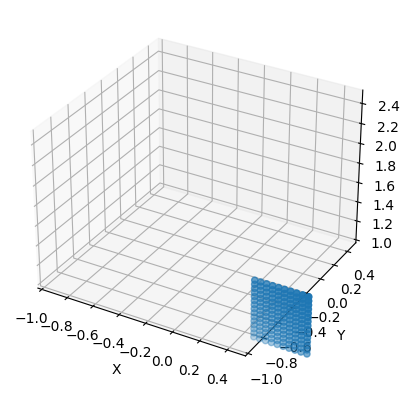

In [84]:
## create viewpoints box#############################################################
%matplotlib inline
plant = 40
plant_data_dir = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_nbv_data/plant%s/xyr_0_0_0'%str(plant)
txt_files = os.listdir(plant_data_dir)
txt_files = [f for f in txt_files if f.endswith('.txt')]

x_y_z_x_y_z_w = []
names = []
for text_file in txt_files:
    path = os.path.join(plant_data_dir, text_file)
    translation_rotation_data = parse_translation_rotation(path)
    try:
        x_y_z_x_y_z_w.append([translation_rotation_data['translation']['x'], translation_rotation_data['translation']['y'], translation_rotation_data['translation']['z'], translation_rotation_data['rotation']['x'], translation_rotation_data['rotation']['y'], translation_rotation_data['rotation']['z'], translation_rotation_data['rotation']['w']])
        names.append(translation_rotation_data['name'][0])
    except:
        print(text_file)

viewpoints = np.array(x_y_z_x_y_z_w, dtype=float)  # Ensure the array is of type float
names = np.array(names)
print(len(names))

min_x = np.min(viewpoints[:, 0])
max_x = np.max(viewpoints[:, 0])

min_z = np.min(viewpoints[:, 2])
max_z = np.max(viewpoints[:, 2])

x_values = np.linspace(min_x, max_x, 10)
z_values = np.linspace(min_z, max_z, 15)

# create meshgrid using x_values and z_values, and length
x, z = np.meshgrid(x_values, z_values)
x, z = x[..., np.newaxis], z[..., np.newaxis]

y, raw, pitch, yaw, w = np.zeros((15, 10, 1)), np.zeros((15, 10, 1)), np.zeros((15, 10, 1)), np.zeros((15, 10, 1)), np.zeros((15, 10, 1))
name = np.empty((15, 10, 1), dtype=object)
box = np.concatenate((x, y, z, raw, pitch, yaw, w, name), axis=-1)

for idx, viewpoint in enumerate(viewpoints):
    x, y, z, roll, pitch, yaw, w = viewpoint
    smallest_distance = 1000
    smallest_h = None
    smallest_w = None
    for h_index in range(15):
        for w_index in range(10):
            distance = abs(x - box[h_index, w_index, 0]) **2+abs(z - box[h_index, w_index, 2])**2
            if distance < smallest_distance:
                smallest_distance = distance
                smallest_h = h_index
                smallest_w = w_index
    box[smallest_h, smallest_w,:] = [x, y, z, roll, pitch, yaw, w, names[idx]]

views = box[..., :7]
print(views.shape)
# visualize the viewpoints using matplotlib using 3D scatter plot
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(views[..., 0], views[..., 1], views[..., 2])
ax.set_xlim(-1, 0.5)
ax.set_ylim(-1, 0.5)
ax.set_zlim(1, 2.5)   

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

np.save('/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_nbv_data/viewpoints_%s.npy'%str(plant), views)

## 1.2 Reaname the file using the box coordinates

In [85]:
save_dir = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_nbv_data/new_name/plant%s/xyr_0_0_0'%str(plant)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

count = 0 
for h_ in range(box.shape[0]): 
    for w_ in range(box.shape[1]):
        if box[h_, w_, -1] is not None:
            count += 1
            pcd_new_name = f'pcd_{h_}_{w_}.pcd'
            rgb_new_name = f'rgb_{h_}_{w_}.jpeg'
            pose_new_name = f'pose_{h_}_{w_}.txt'

            base_name = box[h_, w_, -1].split('.')[0].split('_')[0]
            pcd_old_path = os.path.join(plant_data_dir, base_name + '_b.pcd')
            rgb_old_path = os.path.join(plant_data_dir, base_name + '_color.jpeg')
            pose_old_path = os.path.join(plant_data_dir, base_name + '_pose.txt')

            # copy the file to the new directory with the new name
            pcd_new_path = os.path.join(save_dir, pcd_new_name)
            rgb_new_path = os.path.join(save_dir, rgb_new_name)
            pose_new_path = os.path.join(save_dir, pose_new_name)

            os.system(f'cp {pcd_old_path} {pcd_new_path}')
            os.system(f'cp {rgb_old_path} {rgb_new_path}')
            os.system(f'cp {pose_old_path} {pose_new_path}')
print(count)


150


## 1.3. Crop, Transform, denoise and downsample the partial point cloud

In [87]:
import numpy as np
import os
import open3d as o3d

if __name__ == '__main__':
    voxel_size = 0.003
    plant_list = [31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
    gt_path = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_gt_pcd'
    dir_path = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_nbv_data'

    ########################process partial point cloud########################
    for plant in plant_list:
        gt_pcd_path = os.path.join(gt_path, 'plant%s/tomato%s.ply'%(str(plant), str(plant)))
        gt_pcd = o3d.io.read_point_cloud(gt_pcd_path)

        viewpoints = np.load(os.path.join(dir_path, 'viewpoints_%s.npy'%str(plant)), allow_pickle=True)

        plant_folder = os.path.join(dir_path, 'new_name', 'plant%s'%str(plant), 'xyr_0_0_0')
        files = os.listdir(plant_folder)
        pcds = [file for file in files if file.endswith('.pcd')]

        for pcd_name in pcds:
            pcd_path = os.path.join(plant_folder, pcd_name)
            pcd = o3d.io.read_point_cloud(pcd_path)

            base_name = pcd_name.split('.')[0]
            h, w = base_name.split('_')[1], base_name.split('_')[2]

            pose = viewpoints[int(h), int(w), :]
            pose = pose_to_transformation(pose)

            pcd.transform(pose)
            pcd_down_sampled = downsample_point_cloud(pcd, bbox=bbox, voxel_size=voxel_size)

            #visualize the point cloud
            # vis_PC(center, complete_pcd=None, partial_pcd=pcd_down_sampled, viewpoints_pcd=None, bbox=bbox)
            
            points = np.asarray(pcd_down_sampled.points)[np.newaxis, :, :]
            colors = np.asarray(pcd_down_sampled.colors)[np.newaxis, :, :]
            pcd_xyzrgb = np.concatenate([points, colors], axis=-1)
            # save the points in the same folder with the same base name but with .npy extension
            np.save(os.path.join(plant_folder, base_name+'.npy'), pcd_xyzrgb)

            print(pcd_xyzrgb.shape)

(1, 6526, 6)
(1, 11601, 6)
(1, 26043, 6)
(1, 14303, 6)
(1, 26271, 6)
(1, 12309, 6)
(1, 12464, 6)
(1, 13860, 6)
(1, 8246, 6)
(1, 20257, 6)
(1, 13823, 6)
(1, 16622, 6)
(1, 16582, 6)
(1, 16597, 6)
(1, 14896, 6)
(1, 25837, 6)
(1, 24168, 6)
(1, 22767, 6)
(1, 13463, 6)
(1, 24467, 6)
(1, 21805, 6)
(1, 27465, 6)
(1, 12494, 6)
(1, 6519, 6)
(1, 21372, 6)
(1, 17231, 6)
(1, 12401, 6)
(1, 5318, 6)
(1, 17403, 6)
(1, 18393, 6)
(1, 5034, 6)
(1, 9980, 6)
(1, 16986, 6)
(1, 21424, 6)
(1, 13268, 6)
(1, 11155, 6)
(1, 11940, 6)
(1, 13355, 6)
(1, 6196, 6)
(1, 4422, 6)
(1, 21767, 6)
(1, 5833, 6)
(1, 19638, 6)
(1, 6059, 6)
(1, 10498, 6)
(1, 10192, 6)
(1, 11896, 6)
(1, 23101, 6)
(1, 7923, 6)
(1, 25186, 6)
(1, 24643, 6)
(1, 6894, 6)
(1, 17302, 6)
(1, 21607, 6)
(1, 24379, 6)
(1, 10801, 6)
(1, 25821, 6)
(1, 12474, 6)
(1, 16378, 6)
(1, 23902, 6)
(1, 19680, 6)
(1, 7624, 6)
(1, 9449, 6)
(1, 10855, 6)
(1, 11162, 6)
(1, 13216, 6)
(1, 21122, 6)
(1, 20488, 6)
(1, 21864, 6)
(1, 21100, 6)
(1, 17585, 6)
(1, 18410, 6)
(1, 28

# 2. Process gt pcd

# 2.1. Crop and denoise the .ply for gt point cloud, then store as .npy

In [88]:
import numpy as np
import os
import open3d as o3d
from scipy.spatial.transform import Rotation as R

if __name__ == '__main__':
    voxel_size = 0.003
    plant_list = [31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
    dir_path = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_gt_pcd'
    
    ########################process complete point cloud########################
    for plant in plant_list:
        pcd_name = 'tomato%s.ply'%str(plant)
        pcd_path = os.path.join(dir_path, 'plant%s'%str(plant), pcd_name)
        pcd = o3d.io.read_point_cloud(pcd_path)
        base_name = pcd_name.split('.')[0]
        pcd_down_sampled = downsample_point_cloud(pcd, bbox, voxel_size)
        #visualize the point cloud
        # vis_PC(center, complete_pcd=pcd_down_sampled, partial_pcd=None, viewpoints_pcd=None, bbox=bbox)
        pcd_down_sampled_points = np.asarray(pcd_down_sampled.points)[np.newaxis, :, :]
        pcd_down_sampled_colors = np.asarray(pcd_down_sampled.colors)[np.newaxis, :, :]
        
        pcd_down_sampled_points_colors = np.concatenate([pcd_down_sampled_points, pcd_down_sampled_colors], axis=-1)
        # save the points in the same folder with the same base name but with .npy extension
        np.save(os.path.join(dir_path,'plant%s'%str(plant) ,'downsampled_pcd_0_0_0.npy'), pcd_down_sampled_points_colors)



# 2.2. Align gt to partial point clouds

In [5]:
# Fixed point cloud alignment: GT to accumulated point cloud
import numpy as np
import open3d as o3d
import copy

def prepare_point_cloud_for_icp(pcd, voxel_size=0.003):
    """Prepare point cloud for ICP by computing normals and cleaning up"""
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 2, max_nn=30)
    )
    return pcd
# read the gt pcd
plant_list = [31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
for plant in plant_list:
    print(f"\n=== Processing Plant {plant} ===")
    gt_dir = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_gt_pcd'
    gt_pcd = np.load(os.path.join(gt_dir, 'plant%s'%str(plant), 'downsampled_pcd_0_0_0.npy'))
    gt_pcd_o3d = o3d.geometry.PointCloud()
    gt_pcd_o3d.points = o3d.utility.Vector3dVector(gt_pcd[0, :, :3])
    gt_pcd_o3d.colors = o3d.utility.Vector3dVector(gt_pcd[0, :, 3:])
    # gt_pcd_o3d.paint_uniform_color([0.5, 0.5, 0.5])  # grey for GT

    partial_dir = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_nbv_data/new_name/plant%s/xyzr_0_0_0_0'%str(plant)
    pcd_list = os.listdir(partial_dir)
    pcd_list = [f for f in pcd_list if f.endswith('.npy')]

    acc_ocd = []
    for pcd_name in pcd_list:
        pcd = np.load(os.path.join(partial_dir, pcd_name))
        acc_ocd.append(pcd)

    acc_ocd = np.concatenate(acc_ocd, axis=1)
    acc_ocd_o3d = o3d.geometry.PointCloud()
    acc_ocd_o3d.points = o3d.utility.Vector3dVector(acc_ocd[0,:,:3])
    acc_ocd_o3d.colors = o3d.utility.Vector3dVector(acc_ocd[0,:,3:])

    acc_ocd_o3d = downsample_point_cloud(acc_ocd_o3d, bbox=bbox, voxel_size=voxel_size)

    # Prepare both point clouds for ICP (compute normals, remove outliers)
    print("Preparing point clouds for alignment...")
    acc_ocd_prepared = prepare_point_cloud_for_icp(copy.deepcopy(acc_ocd_o3d), voxel_size=voxel_size)
    gt_pcd_prepared = prepare_point_cloud_for_icp(copy.deepcopy(gt_pcd_o3d), voxel_size=voxel_size)
    
    # Method 1: Point-to-Point ICP (more robust, doesn't require normals)
    print("Performing Point-to-Point ICP alignment...")
    icp_p2p = o3d.pipelines.registration.registration_icp(
        gt_pcd_prepared, acc_ocd_prepared, voxel_size, np.eye(4),
        o3d.pipelines.registration.TransformationEstimationPointToPoint()
    )
    
    # Method 2: Point-to-Plane ICP (now with normals computed)
    print("Performing Point-to-Plane ICP alignment...")
    icp_p2plane = o3d.pipelines.registration.registration_icp(
        gt_pcd_prepared, acc_ocd_prepared, voxel_size, icp_p2p.transformation,
        o3d.pipelines.registration.TransformationEstimationPointToPlane()
    )
    
    print(f"Point-to-Point ICP - Fitness: {icp_p2p.fitness:.4f}, RMSE: {icp_p2p.inlier_rmse:.4f}")
    print(f"Point-to-Plane ICP - Fitness: {icp_p2plane.fitness:.4f}, RMSE: {icp_p2plane.inlier_rmse:.4f}")
    
    # Apply transformation to GT point cloud (align GT to accumulated)
    gt_pcd_aligned = copy.deepcopy(gt_pcd_o3d)
    gt_pcd_aligned.transform(icp_p2plane.transformation)
    # gt_pcd_aligned.paint_uniform_color([0, 0, 1])  # Blue for aligned GT

    # save the aligned gt_pcd on the same folder as gt_pcd but with the name of plant_aligned.npy
    gt_pcd_aligned_points = np.asarray(gt_pcd_aligned.points)[np.newaxis, :, :]
    gt_pcd_aligned_colors = np.asarray(gt_pcd_aligned.colors)[np.newaxis, :, :]
    gt_pcd_aligned_points_colors = np.concatenate([gt_pcd_aligned_points, gt_pcd_aligned_colors], axis=-1)
    # np.save(os.path.join(gt_dir, f'plant{plant}_aligned.npy'), gt_pcd_aligned_points_colors)
    # store the point cloud as .pcd
    o3d.io.write_point_cloud(os.path.join(gt_dir, 'plant%s.pcd'%str(plant)), gt_pcd_aligned)


    

    



=== Processing Plant 31 ===
Preparing point clouds for alignment...
Performing Point-to-Point ICP alignment...
Performing Point-to-Plane ICP alignment...
Point-to-Point ICP - Fitness: 0.7341, RMSE: 0.0015
Point-to-Plane ICP - Fitness: 0.8585, RMSE: 0.0016

=== Processing Plant 32 ===
Preparing point clouds for alignment...
Performing Point-to-Point ICP alignment...
Performing Point-to-Plane ICP alignment...
Point-to-Point ICP - Fitness: 0.7807, RMSE: 0.0014
Point-to-Plane ICP - Fitness: 0.8464, RMSE: 0.0016

=== Processing Plant 33 ===
Preparing point clouds for alignment...
Performing Point-to-Point ICP alignment...
Performing Point-to-Plane ICP alignment...
Point-to-Point ICP - Fitness: 0.6885, RMSE: 0.0014
Point-to-Plane ICP - Fitness: 0.7768, RMSE: 0.0017

=== Processing Plant 34 ===
Preparing point clouds for alignment...
Performing Point-to-Point ICP alignment...
Performing Point-to-Plane ICP alignment...
Point-to-Point ICP - Fitness: 0.8016, RMSE: 0.0013
Point-to-Plane ICP - Fi

# 3. Final test of coverage

In [95]:
# usr/bin/env python3
import numpy as np
import os
import open3d as o3d
from scipy.spatial.transform import Rotation as R
import torch
# add this path to the python path
import sys
sys.path.append('/home/jianchao/ros_workspace/paper4_semantic_nbv/src/networks/src/networks')
from chamfer import chamfer_distance

def cal_coverage(partial_pc, complete_pc, thr=0.003):
    '''
        partial_pc: 6 channels-xyzrgb.
    '''
    if not partial_pc.is_cuda:
        partial_pc = partial_pc.to('cuda')
    _, dist2 = get_chamfer_dists(partial_pc[..., 0:3], complete_pc)
    covered_points = dist2 < thr
    cov_ratio = torch.sum(covered_points).item() / covered_points.shape[1]
    return '%s/%s' % (str(torch.sum(covered_points).item()),
                        str(covered_points.shape[1])), cov_ratio

def get_chamfer_dists(pcd_x, pcd_y):
    # We compare the two sets of pointclouds by computing the chamfer loss.
    _, _, dist_x, dist_y = chamfer_distance(pcd_x, pcd_y)
    dist_x = dist_x.cpu().detach()
    dist_y = dist_y.cpu().detach()

    return dist_x, dist_y
# read the gt pcd
plant_list = [31, 32, 33, 34, 35, 36, 37, 38, 39, 40]

for plant in plant_list:
    gt_pcd = np.load('/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_gt_pcd/plant%s/plant%s_aligned.npy'%(str(plant), str(plant)))
    print(gt_pcd.shape)
    gt_pcd_o3d = o3d.geometry.PointCloud()
    gt_pcd_o3d.points = o3d.utility.Vector3dVector(gt_pcd[0, :, :3])
    gt_pcd_o3d.paint_uniform_color([0.5, 0.5, 0.5])  # grey

    partial_dir = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_nbv_data/new_name/plant%s/xyr_0_0_0'%str(plant)
    pcd_list = os.listdir(partial_dir)
    pcd_list = [f for f in pcd_list if f.endswith('.npy')]

    acc_pcd = []
    for pcd_name in pcd_list:
        pcd = np.load(os.path.join(partial_dir, pcd_name))
        acc_pcd.append(pcd)

    acc_pcd = np.concatenate(acc_pcd, axis=1)
    acc_pcd_o3d = o3d.geometry.PointCloud()
    acc_pcd_o3d.points = o3d.utility.Vector3dVector(acc_pcd[0,:,:3])  # Fixed: use acc_pcd instead of acc_ocd
    acc_pcd_o3d.paint_uniform_color([0, 1, 0])  # green

    # Downsample accumulated point cloud
    acc_pcd_o3d = downsample_point_cloud(acc_pcd_o3d, bbox=bbox, voxel_size=voxel_size)
    
    # Convert to numpy arrays to get shape information
    acc_pcd_points = np.asarray(acc_pcd_o3d.points)
    
    print(f"Number of points - Accumulated: {len(acc_pcd_o3d.points)}, GT: {gt_pcd.shape}")

    # # calculate the coverage
    print(torch.tensor(acc_pcd_points).cuda().unsqueeze(0).shape)
    print(torch.tensor(gt_pcd).cuda().shape)
    
    cal = cal_coverage(torch.from_numpy(acc_pcd_points).cuda().unsqueeze(0), torch.from_numpy(gt_pcd[..., :3]).cuda(), thr=voxel_size)
    print(cal)
    
    # Optional: Visualize the point clouds
    o3d.visualization.draw_geometries([acc_pcd_o3d, gt_pcd_o3d], 
                                      window_name=f'Plant {plant} - Before Alignment', 
                                      width=800, height=600)


(1, 133027, 6)
Number of points - Accumulated: 349424, GT: (1, 133027, 6)
torch.Size([1, 349424, 3])
torch.Size([1, 133027, 6])
('114490/133027', 0.860652348771302)
(1, 173552, 6)
Number of points - Accumulated: 437048, GT: (1, 173552, 6)
torch.Size([1, 437048, 3])
torch.Size([1, 173552, 6])
('146877/173552', 0.8462996681109984)


KeyboardInterrupt: 

# 4. Align annotation as well

In [160]:
# Fixed point cloud alignment: GT to accumulated point cloud
import numpy as np
import open3d as o3d
import copy
import pandas as pd
import os

def prepare_point_cloud_for_icp(pcd, voxel_size=0.003):
    """Prepare point cloud for ICP by computing normals and cleaning up"""
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 2, max_nn=30)
    )
    return pcd

# read the gt pcd
plant_list = [31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
for plant in plant_list:
    print(f"\n=== Processing Plant {plant} ===")
    gt_dir = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_gt_pcd'
    gt_pcd = np.load(os.path.join(gt_dir, 'plant%s'%str(plant), 'downsampled_pcd_0_0_0.npy'))
    gt_pcd_o3d = o3d.geometry.PointCloud()
    gt_pcd_o3d.points = o3d.utility.Vector3dVector(gt_pcd[0, :, :3])
    gt_pcd_o3d.colors = o3d.utility.Vector3dVector(gt_pcd[0, :, 3:])
    # gt_pcd_o3d.paint_uniform_color([0.5, 0.5, 0.5])  # grey for GT

    partial_dir = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_nbv_data/new_name/plant%s/xyr_0_0_0'%str(plant)
    pcd_list = os.listdir(partial_dir)
    pcd_list = [f for f in pcd_list if f.endswith('.npy')]

    annotaiton_dir = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_anno'
    # read the annotation file with only read
    annotation_file = pd.read_excel(os.path.join(annotaiton_dir, 'plant%s_object_poses.xlsx'%str(plant)) )

    acc_ocd = []
    for pcd_name in pcd_list:
        pcd = np.load(os.path.join(partial_dir, pcd_name))
        acc_ocd.append(pcd)

    acc_ocd = np.concatenate(acc_ocd, axis=1)
    acc_ocd_o3d = o3d.geometry.PointCloud()
    acc_ocd_o3d.points = o3d.utility.Vector3dVector(acc_ocd[0,:,:3])
    acc_ocd_o3d.paint_uniform_color([0, 1, 0])  # Green for accumulated

    acc_ocd_o3d = downsample_point_cloud(acc_ocd_o3d, bbox=bbox, voxel_size=voxel_size)

    # Prepare both point clouds for ICP (compute normals, remove outliers)
    print("Preparing point clouds for alignment...")
    acc_ocd_prepared = prepare_point_cloud_for_icp(copy.deepcopy(acc_ocd_o3d), voxel_size=voxel_size)
    gt_pcd_prepared = prepare_point_cloud_for_icp(copy.deepcopy(gt_pcd_o3d), voxel_size=voxel_size)
    
    # Method 1: Point-to-Point ICP (more robust, doesn't require normals)
    print("Performing Point-to-Point ICP alignment...")
    icp_p2p = o3d.pipelines.registration.registration_icp(
        gt_pcd_prepared, acc_ocd_prepared, voxel_size, np.eye(4),
        o3d.pipelines.registration.TransformationEstimationPointToPoint()
    )
    
    # Method 2: Point-to-Plane ICP (now with normals computed)
    print("Performing Point-to-Plane ICP alignment...")
    icp_p2plane = o3d.pipelines.registration.registration_icp(
        gt_pcd_prepared, acc_ocd_prepared, voxel_size, icp_p2p.transformation,
        o3d.pipelines.registration.TransformationEstimationPointToPlane()
    )
    
    print(f"Point-to-Point ICP - Fitness: {icp_p2p.fitness:.4f}, RMSE: {icp_p2p.inlier_rmse:.4f}")
    print(f"Point-to-Plane ICP - Fitness: {icp_p2plane.fitness:.4f}, RMSE: {icp_p2plane.inlier_rmse:.4f}")
    
    # Apply transformation to GT point cloud (align GT to accumulated)
    gt_pcd_aligned = copy.deepcopy(gt_pcd_o3d)
    gt_pcd_aligned.transform(icp_p2plane.transformation)
    # gt_pcd_aligned.paint_uniform_color([0, 0, 1])  # Blue for aligned GT

    fruit_annotation_file_aligned = pd.DataFrame()
    node_annotation_file_aligned = pd.DataFrame()
    for index, row in annotation_file.iterrows():
        # get the name of the column
        bbox_name = row.object
        print(bbox_name)
        bbox_center = np.array([row['x'], row['y'], row['z']])
        bbox_center_aligned = icp_p2plane.transformation[:3, :3] @ bbox_center + icp_p2plane.transformation[:3, 3]
        if bbox_name.startswith('P'):
            node_annotation_file_aligned.at[index, 'loc_x'] = bbox_center_aligned[0]
            node_annotation_file_aligned.at[index, 'loc_y'] = bbox_center_aligned[1]
            node_annotation_file_aligned.at[index, 'loc_z'] = bbox_center_aligned[2]
            node_annotation_file_aligned.at[index, 'dir_x'] = 0
            node_annotation_file_aligned.at[index, 'dir_y'] = 0
            node_annotation_file_aligned.at[index, 'dir_z'] = 1
        elif bbox_name.startswith('F'):
            fruit_annotation_file_aligned.at[index, 'loc_x'] = bbox_center_aligned[0]
            fruit_annotation_file_aligned.at[index, 'loc_y'] = bbox_center_aligned[1]
            fruit_annotation_file_aligned.at[index, 'loc_z'] = bbox_center_aligned[2]
            fruit_annotation_file_aligned.at[index, 'radius'] = 0.06/2

    # save the annotation_file_aligned
    fruit_annotation_file_aligned.to_csv(os.path.join(annotaiton_dir, 'plant%s_export_fruit.csv'%str(plant)), index=False)
    node_annotation_file_aligned.to_csv(os.path.join(annotaiton_dir, 'plant%s_export_node.csv'%str(plant)), index=False)



=== Processing Plant 31 ===
Preparing point clouds for alignment...
Performing Point-to-Point ICP alignment...
Performing Point-to-Plane ICP alignment...
Point-to-Point ICP - Fitness: 0.9528, RMSE: 0.0030
Point-to-Plane ICP - Fitness: 0.9576, RMSE: 0.0029
PT1
PT2
PT3
PT4
PT5
PT6
PT7
PT6
PD8
F1
F2
F3
F4
F5

=== Processing Plant 32 ===
Preparing point clouds for alignment...
Performing Point-to-Point ICP alignment...
Performing Point-to-Plane ICP alignment...
Point-to-Point ICP - Fitness: 0.9530, RMSE: 0.0030
Point-to-Plane ICP - Fitness: 0.9702, RMSE: 0.0029
PT1
PT2
PT3
PT4
PT5
PT6
PT7

=== Processing Plant 33 ===
Preparing point clouds for alignment...
Performing Point-to-Point ICP alignment...
Performing Point-to-Plane ICP alignment...
Point-to-Point ICP - Fitness: 0.9238, RMSE: 0.0031
Point-to-Plane ICP - Fitness: 0.9324, RMSE: 0.0031
PT1
PT2
PT3
PD1
F1
F2
F3
F4

=== Processing Plant 34 ===
Preparing point clouds for alignment...
Performing Point-to-Point ICP alignment...
Performing

# 5. Visualize annoation BBox

In [6]:
import pandas as pd
import numpy as np
import open3d as o3d
import os

plant_list = [31, 32, 33, 34, 35, 36, 37, 38, 39, 40] # 32 has no fruit bbox
# give me 11 unique colors in rgb order # green, blue, red, yellow, purple, cyan, brown, pink, orange, gray, black
colors = [[0, 1, 0], [0, 0, 1], [1, 0, 0], [1, 1, 0], [1, 0, 1], [0, 1, 1], [0.5, 0.5, 0], [0.5, 0, 0.5], [1, 0.5, 0], [0.5, 0.5, 0.5], [0, 0, 0]]

for plant in plant_list:
    gt_pcd = np.load('/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_gt_pcd/plant%s/plant%s_aligned.npy'%(str(plant), str(plant)))
    print(gt_pcd.shape)
    gt_pcd_o3d = o3d.geometry.PointCloud()
    gt_pcd_o3d.points = o3d.utility.Vector3dVector(gt_pcd[0, :, :3])
    # gt_pcd_o3d.colors = o3d.utility.Vector3dVector(gt_pcd[0, :, 3:])
    gt_pcd_o3d.paint_uniform_color([0.5, 0.5, 0.5])

    partial_dir = '/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_nbv_data/new_name/plant%s/xyzr_0_0_0_0'%str(plant)
    pcd_list = os.listdir(partial_dir)
    pcd_list = [f for f in pcd_list if f.endswith('.npy')]

    acc_pcd = []
    for pcd_name in pcd_list:
        pcd = np.load(os.path.join(partial_dir, pcd_name))
        acc_pcd.append(pcd)

    acc_pcd = np.concatenate(acc_pcd, axis=1)
    acc_pcd_o3d = o3d.geometry.PointCloud()
    acc_pcd_o3d.points = o3d.utility.Vector3dVector(acc_pcd[0, :,:3])  # Fixed: use acc_pcd instead of acc_ocd
    acc_pcd_o3d.colors = o3d.utility.Vector3dVector(acc_pcd[0, :, 3:])
    # acc_pcd_o3d.paint_uniform_color([0, 1, 0])

    # Downsample accumulated point cloud
    acc_pcd_o3d = downsample_point_cloud(acc_pcd_o3d, bbox=bbox, voxel_size=voxel_size)

    dim = 0.06
    fruit_bbox_list = []
    node_bbox_list = []
    try:
        fruit_poses  =  pd.read_csv('/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_anno/plant%s_export_fruit.csv'%(str(plant)))
        fruit_poses = fruit_poses[['loc_x', 'loc_y', 'loc_z']].values

        for idx,  pose in enumerate(fruit_poses):   
            fruit_bbox_o3d = o3d.geometry.AxisAlignedBoundingBox(min_bound=pose-dim/2, max_bound=pose+dim/2)
            fruit_bbox_o3d.color = colors[idx]
            fruit_bbox_list.append(fruit_bbox_o3d)
    except:
        print(f'Plant {plant} has no fruit bbox')
    
    try:
        node_poses = pd.read_csv('/home/jianchao/dataset/nbv_data/paper4/real_world_data_new/real_anno/plant%s_export_internode.csv'%(str(plant)))
        node_poses = node_poses[['loc_x', 'loc_y', 'loc_z']].values
      
        for idx, pose in enumerate(node_poses):
            node_bbox_o3d = o3d.geometry.AxisAlignedBoundingBox(min_bound=pose-dim/2, max_bound=pose+dim/2)
            node_bbox_o3d.color = colors[idx]
            node_bbox_list.append(node_bbox_o3d)
    except:
        print(f'Plant {plant} has no node bbox')
    
    coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1)
    # Optional: Visualize the point clouds
    o3d.visualization.draw_geometries([acc_pcd_o3d, *fruit_bbox_list, *node_bbox_list, coordinate_frame], 
                                      window_name=f'Plant {plant} - Aligned', 
                                      width=800, height=600)


(1, 133027, 6)
(1, 173552, 6)
(1, 259932, 6)
(1, 185141, 6)
(1, 123958, 6)
(1, 95114, 6)
(1, 62080, 6)
(1, 127727, 6)
(1, 153175, 6)
(1, 97408, 6)
